# Housing Price Analysis — Inflation Adjustment & Price Distribution (1400–1403)

This notebook conducts two key empirical analyses on property sales transactions:
1. **CPI Inflation Adjustment:** Decomposing nominal price trajectory into real purchasing power using the Consumer Price Index with base year 1400 ($CPI_{1400} = 100$).
2. **Cross-Category Price Distribution:** Examining price central tendencies (median) and dispersion across property types after filtering out upper extreme outliers (95th percentile).


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure project root directory to import internal modules
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from source.price_analysis import (
    prepare_sales_data,
    compute_real_prices,
    plot_nominal_vs_real_price,
    plot_category_price_distribution,
)

# Load preprocessed dataset
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "preprocessing_output_v4.parquet"
df = pd.read_parquet(DATA_PATH)

print(f"Data loaded successfully. Total rows: {len(df):,}, Columns: {df.shape[1]}")
df.head(3)

Data loaded successfully. Total rows: 1,000,000, Columns: 98


,Unnamed: 0,city_slug,description,title,rent_mode,rent_value,price_mode,price_value,credit_mode,credit_value,...,land_size_was_missing,floor_was_missing,rooms_count_was_missing,total_floors_count_was_missing,unit_per_floor_was_missing,construction_year_was_missing,building_age,is_rebuilt_was_missing,deed_type_was_missing,has_business_deed_was_missing
0,0,karaj,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,<NA>,NaN,<NA>,NaN,<NA>,NaN,...,1,1,0,1,1,1,9.0,1,1,1
1,1,tehran,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,<NA>,NaN,مقطوع,8.500000e+09,<NA>,NaN,...,1,0,0,1,1,0,20.0,1,1,1
2,2,tehran,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,<NA>,NaN,مقطوع,750000000.0,...,1,0,0,1,1,0,3.0,0,1,1


In [2]:
# Filter confirmed sales transactions within target timeframe (1400–1403)
df_sales = prepare_sales_data(df, min_year=1400, max_year=1403)

print(f"Valid sales records (1400–1403): {len(df_sales):,}")
df_sales[["clean_year", "property_type", "price_value"]].head(5)

Valid sales records (1400–1403): 166,890


,clean_year,property_type,price_value
4,1403,apartment,5.750000e+09
10,1403,apartment,2.600000e+09
12,1403,apartment,1.299000e+10
13,1400,shop,8.500000e+08
24,1403,villa,1.800000e+09


### 1. Nominal Price Deflation via CPI

To isolate real economic purchasing power from monetary inflation, nominal transaction prices are deflated using the Consumer Price Index with base year 1400 ($CPI_{1400} = 100$):

$$Real\_Price = Nominal\_Price \times \left(\frac{CPI_{1400}}{CPI_{year}}\right)$$


,clean_year,count,mean_nominal,median_nominal,cpi,mean_real,median_real
0,1400,25060,8.886141e+09,3.000000e+09,100.0,8.886141e+09,3.000000e+09
1,1401,20136,1.075313e+10,3.500000e+09,145.8,7.375259e+09,2.400549e+09
2,1402,39049,1.038815e+10,3.700000e+09,205.1,5.064921e+09,1.803998e+09
3,1403,82645,1.146126e+10,3.970000e+09,270.7,4.233936e+09,1.466568e+09


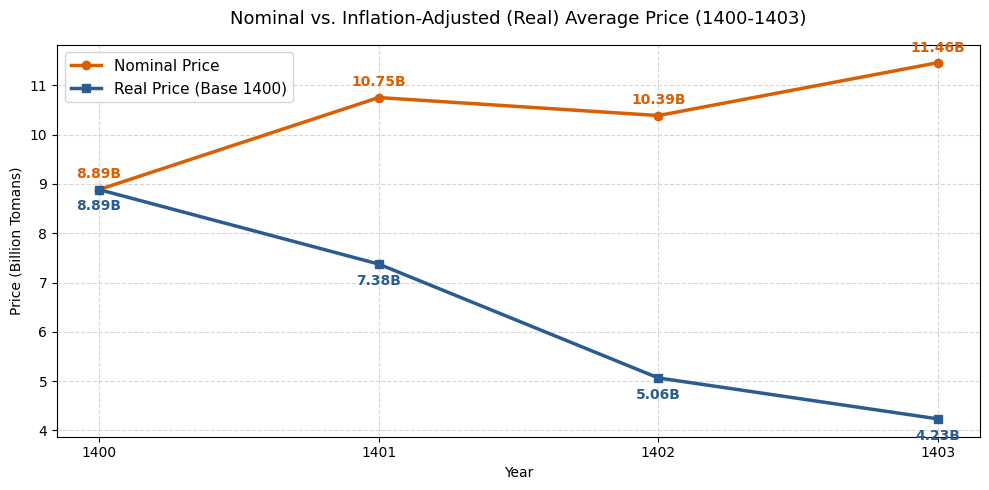

In [6]:
# Compute nominal vs. real price summary statistics across years
summary_prices = compute_real_prices(df_sales)

# Display tabular indicators and averages
display(summary_prices)

# Plot nominal vs. real price trajectory
plot_nominal_vs_real_price(summary_prices)

### Nominal vs. Real Price Trend Insights:
1. **Money Illusion:** While nominal prices exhibit a persistent upward trajectory from 1400 to 1403, CPI deflation reveals this expansion was driven primarily by macro inflation rather than real asset appreciation.
2. **Contraction in Real Purchasing Power:** Real average prices contracted over the observed window, indicating that headline consumer basket inflation outpaced nominal housing price gains during this period.


C:\Users\98936\AppData\Local\Temp\ipykernel_82868\2962728618.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


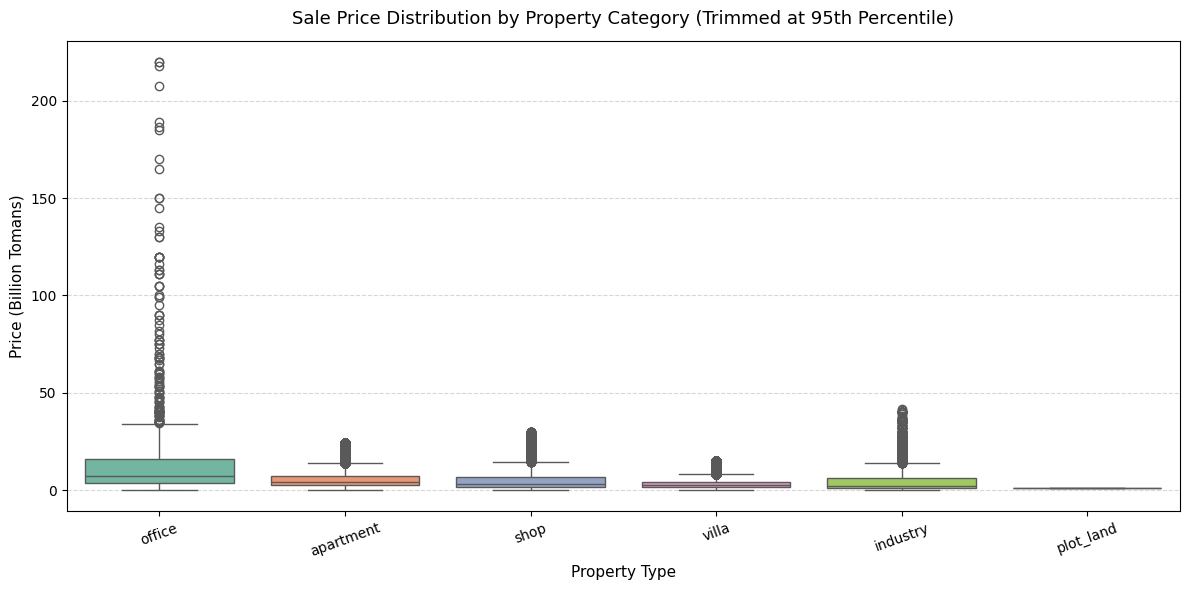

In [4]:
# 1. Filter out unknown categories
df_plot = df_sales[df_sales["property_type"] != "unknown"].copy()

# 2. Trim upper 5% outliers per category using modern pandas transform (safe & fast)
upper_limit = df_plot.groupby("property_type")["price_value"].transform(
    lambda s: s.quantile(0.95)
)
df_trimmed = df_plot[df_plot["price_value"] <= upper_limit].copy()
df_trimmed["price_billion"] = df_trimmed["price_value"] / 1e9

# 3. Sort categories by median price descending
order = (
    df_trimmed.groupby("property_type")["price_billion"]
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_trimmed, x="property_type", y="price_billion", order=order, palette="Set2"
)

plt.title(
    "Sale Price Distribution by Property Category (Trimmed at 95th Percentile)",
    fontsize=13,
    pad=12,
)
plt.xlabel("Property Type", fontsize=11)
plt.ylabel("Price (Billion Tomans)", fontsize=11)
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# 1. If you have the prepared sales DataFrame under another name, let's inspect it
# If the variable df_sales exists in your notebook:
target_df = df_sales if "df_sales" in locals() else df

print("Columns related to category / villa:")
matching_cols = [
    c
    for c in target_df.columns
    if any(k in c.lower() for k in ["cat", "type", "villa", "property"])
]
print(matching_cols)

Columns related to category / villa:
['deed_type', 'location_latitude', 'location_longitude', 'deal_type_other', 'deal_type_rent', 'deal_type_sell', 'deal_type_temporary_rent', 'property_category_apartment', 'property_category_industry', 'property_category_office', 'property_category_other', 'property_category_plot_land', 'property_category_shop', 'property_category_villa', 'user_type_شخصی', 'user_type_مشاور املاک', 'deed_type_was_missing', 'property_type']


In [14]:
import numpy as np
import pandas as pd

# Select the DataFrame
target_df = df_sales if "df_sales" in locals() else df

# Filter villas
if "property_type" in target_df.columns:
    villa_df = target_df[
        target_df["property_type"].astype(str).str.lower() == "villa"
    ].copy()
else:
    villa_df = target_df[target_df["property_category_villa"] == 1].copy()

print(f"Total villa records: {len(villa_df):,}")
print("=" * 65)

# 1. Automatically identify a possible area column
area_candidates = [
    c
    for c in target_df.columns
    if any(k in c.lower() for k in ["area", "size", "meter", "space", "metr", "scale"])
]
print(f"Possible area columns: {area_candidates}")

area_col = area_candidates[0] if area_candidates else None
price_col = "price_value" if "price_value" in villa_df.columns else "price"

print(f"Selected price column: {price_col}")
print(f"Selected area column: {area_col}")
print("=" * 65)

# 2. Summarize villa prices
print("--- 1. Villa price summary (Tomans) ---")
price_stats = villa_df[price_col].describe()
for stat_name, val in price_stats.items():
    print(f"{stat_name:10s} : {val:,.2f}")
print("=" * 65)

# Key villa price percentiles
quantiles = villa_df[price_col].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("--- Villa price percentiles (billions of Tomans) ---")
for q, val in quantiles.items():
    print(f"{int(q * 100):2d}th percentile: {val / 1e9:,.3f} billion Tomans")
print("=" * 65)

# 3. If an area column is found, summarize area and calculate price per square meter
if area_col:
    print(f"--- 2. Villa area summary (column: {area_col}) ---")
    area_stats = villa_df[area_col].describe()
    for stat_name, val in area_stats.items():
        print(f"{stat_name:10s} : {val:,.2f}")
    print("=" * 65)

    valid = villa_df[(villa_df[price_col] > 0) & (villa_df[area_col] > 0)].copy()

    valid["price_per_m2_million"] = (
        valid[price_col] / valid[area_col]
    ) / 1e6  # Million Tomans per square meter

    print("--- 3. Villa price per square meter (million Tomans) ---")
    print(
        f"Median price per m²: "
        f"{valid['price_per_m2_million'].median():,.2f} million Tomans"
    )
    print(
        f"Mean price per m²: "
        f"{valid['price_per_m2_million'].mean():,.2f} million Tomans"
    )

Total villa records: 49,761
Possible area columns: ['land_size', 'building_size', 'building_size_was_missing', 'land_size_was_missing']
Selected price column: price_value
Selected area column: land_size
--- 1. Villa price summary (Tomans) ---
count      : 49,761.00
mean       : 7,224,662,062.74
std        : 86,886,438,893.74
min        : 10,000,000.00
25%        : 1,500,000,000.00
50%        : 2,500,000,000.00
75%        : 4,600,000,000.00
max        : 8,300,000,000,000.00
--- Villa price percentiles (billions of Tomans) ---
10th percentile: 0.850 billion Tomans
25th percentile: 1.500 billion Tomans
50th percentile: 2.500 billion Tomans
75th percentile: 4.600 billion Tomans
90th percentile: 9.300 billion Tomans
95th percentile: 15.000 billion Tomans
99th percentile: 50.000 billion Tomans
--- 2. Villa area summary (column: land_size) ---
count      : 49,761.00
mean       : 3,033.43
std        : 105,674.34
min        : 1.00
25%        : 171.00
50%        : 240.00
75%        : 350.00
max 

In [15]:
# 1. Price per square meter of building size (useful floor area)
if "building_size" in villa_df.columns:
    valid_b = villa_df[
        (villa_df["price_value"] > 0) & (villa_df["building_size"] > 0)
    ].copy()
    valid_b["price_per_b_m2"] = (
        valid_b["price_value"] / valid_b["building_size"]
    ) / 1e6
    print("--- Villa Price per Square Meter of Building Size (Million Tomans) ---")
    print(f"Median building size       : {valid_b['building_size'].median():,.0f} m²")
    print(
        f"Median price per m² (floor): {valid_b['price_per_b_m2'].median():,.2f} million Tomans"
    )
    print("=" * 60)

# 2. Distribution of villas across metropolises vs. small cities/villages
if "is_metropolis" in villa_df.columns:
    print("--- Share of Villas in Metropolises vs. Other Regions ---")
    print(
        villa_df["is_metropolis"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .astype(str)
        + " %"
    )

--- Villa Price per Square Meter of Building Size (Million Tomans) ---
Median building size       : 130 m²
Median price per m² (floor): 20.00 million Tomans


### Property Category Price Distribution (Box Plot Analysis):
* **Commercial & Office:** Commercial units and retail spaces demonstrate higher median valuations and substantial variance, driven by premium commercial zoning, goodwill value (*Sarghofli*), and heterogeneous square footage.
* **Residential Units (Apartments & Villas):** Standard apartments display a compact, homogeneous distribution with lower variance around the market median.
* **Land & Plots:** Marked by wide dispersion attributable to disparate lot sizes, development density coefficients, and location tiers.

> **Methodological Note:**
> Cross-market total price comparisons aggregate both unit value and surface area disparities. For granular micro-market valuation, normalizing by unit area (`price_per_meter`) and stratifying by municipal district is recommended for downstream econometric models.


## 4. Hypothesis Testing: Residential Area in Metropolises vs. Small Cities / Rural Areas

**Hypothesis Formulation:**
* **Null Hypothesis ($H_0$):** $\mu_{\text{metropolis}} \ge \mu_{\text{small/rural}}$ (Average residential area in metropolises is greater than or equal to small cities/rural areas)
* **Alternative Hypothesis ($H_1$):** $\mu_{\text{metropolis}} < \mu_{\text{small/rural}}$ (Average residential area in metropolises is smaller)
* **Significance Level ($\alpha$):** 0.01


Loading data from C:\Users\98936\Desktop\divar-housing-analysis\data\processed\preprocessing_output_v4.parquet...
Filtered to residential properties: 731,060 records remaining.

                  DESCRIPTIVE STATISTICS
Metropolis:    N = 362,477 | Mean = 115.72 m² | Median = 100.0 m² | Std = 76.12
Small Cities:  N = 336,740 | Mean = 118.96 m² | Median = 100.0 m² | Std = 80.46
Difference in Means (Metro - Small): -3.24 m²

                    HYPOTHESIS TEST RESULTS
Welch's t-statistic : -17.2666
p-value (Welch's)   : 4.3381e-67
Mann-Whitney U p-val: 9.2967e-70
Cohen's d           : -0.0414
------------------------------------------------------------
✅ RESULT: The null hypothesis is REJECTED (p < 0.01).
   -> The dataset SUPPORTS the hypothesis that residential units
      in metropolises have significantly smaller mean area.

Chart saved to C:\Users\98936\Desktop\divar-housing-analysis\outputs\figures\area_distribution.png


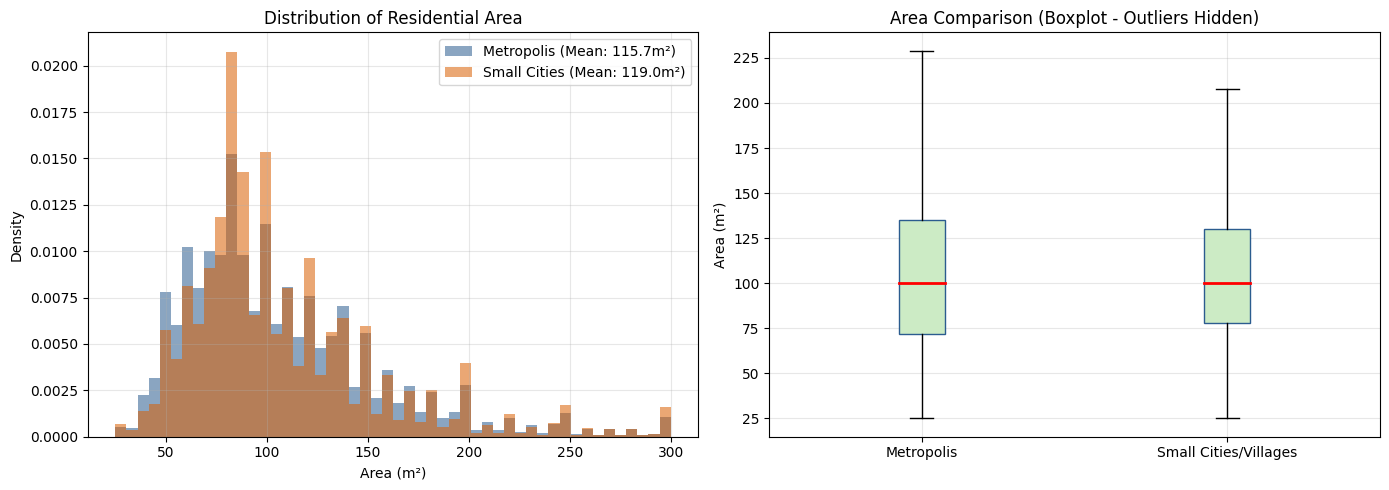

In [5]:
# Define project root
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path("..").resolve()

# Add project root to system path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import statistical test functions
try:
    from hypothesis_area_test import (
        load_and_prepare_data,
        run_hypothesis_test,
        plot_results,
    )
except ModuleNotFoundError:
    from source.hypothesis_area_test import (
        load_and_prepare_data,
        run_hypothesis_test,
        plot_results,
    )

# 1. Define file paths
parquet_file = PROJECT_ROOT / "data" / "processed" / "preprocessing_output_v4.parquet"
city_csv_file = PROJECT_ROOT / "data" / "raw" / "iran_city_classification.csv"

# 2. Load and merge datasets
df_area = load_and_prepare_data(parquet_path=parquet_file, city_csv_path=city_csv_file)

# 3. Run statistical hypothesis test (Significance level alpha=0.01 is predefined in the module)
run_hypothesis_test(df_area)

# 4. Separate residential areas for metropolises vs. small cities/rural areas
metro_area = df_area[df_area["is_metropolis"]]["area_clean"].values
small_area = df_area[~df_area["is_metropolis"]]["area_clean"].values

# 5. Plot and save the distribution comparison
output_chart = PROJECT_ROOT / "outputs" / "figures" / "area_distribution.png"
plot_results(metro_area, small_area, output_path=output_chart)
plt.show()

### Hypothesis Testing & Interpretation: Residential Area (Metropolises vs. Small Cities/Villages)

#### 1. Hypothesis Formalization
To evaluate whether high population density and migration have resulted in smaller living spaces in major urban centers, we set up a one-tailed statistical hypothesis test:

* **Null Hypothesis ($H_0$):** $\mu_{\text{metropolis}} \ge \mu_{\text{small\_cities}}$  
  *(The average residential area in metropolises is greater than or equal to that of small cities and rural areas)*
* **Alternative Hypothesis ($H_1$):** $\mu_{\text{metropolis}} < \mu_{\text{small\_cities}}$  
  *(The average residential area in metropolises is strictly smaller than that of small cities and rural areas)*
* **Significance Level ($\alpha$):** $0.01$ (1%)

---

#### 2. Summary & Statistical Test Results

| Metric / Test | Metropolis ($N = 362,477$) | Small Cities / Rural ($N = 336,740$) | Difference / Statistic |
| :--- | :---: | :---: | :---: |
| **Sample Mean ($\mu$)** | **$115.72\text{ m}^2$** | **$118.96\text{ m}^2$** | **$-3.24\text{ m}^2$** |
| **Median** | $100.0\text{ m}^2$ | $100.0\text{ m}^2$ | $0.0\text{ m}^2$ |
| **Standard Deviation ($\sigma$)** | $76.12$ | $80.46$ | — |
| **Welch's $t$-test ($t$-stat / $p$-val)** | — | — | $t = -17.27,\; p \approx 4.34 \times 10^{-67}$ |
| **Mann-Whitney $U$ Test ($p$-val)** | — | — | $p \approx 9.30 \times 10^{-70}$ |
| **Cohen's $d$ (Effect Size)** | — | — | $d = -0.0414$ |

---

#### 3. Key Findings & Discussion

1. **Rejection of the Null Hypothesis ($H_0$):**
   * Both parametric (**Welch's $t$-test**, $p \approx 4.34 \times 10^{-67}$) and non-parametric (**Mann-Whitney $U$**, $p \approx 9.30 \times 10^{-70}$) tests yield $p$-values far below the significance threshold ($\alpha = 0.01$).
   * **Conclusion:** The dataset **statistically supports the hypothesis** that residential units in metropolises have a significantly smaller mean area compared to smaller cities and rural regions.

2. **Statistical Significance vs. Practical Significance (Effect Size):**
   * **Mean Difference:** Metropolis residential units are on average **$\approx 3.24\text{ m}^2$ smaller**.
   * **Cohen's $d$ ($-0.041$):** While the extreme sample size ($N > 699\text{k}$) produces massive statistical significance, the standardized effect size is categorized as **very small / negligible** ($|d| < 0.2$).
   * **Median Comparison:** Both groups share an identical median of **$100\text{ m}^2$**, reflecting standard apartment building norms across the country. However, as seen in the density distribution plot, metropolises exhibit a higher density of compact units ($50\text{--}80\text{ m}^2$), whereas smaller cities show longer tails toward larger unit sizes.
